# VEP

Variant Effect Prediction (VEP) using Protein Language Models.

In [40]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
os.chdir(os.path.dirname(os.path.abspath('.')))

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import data

### Candidate proteins
A curated list of proteins that clinically relevant and incompletely penetrant across different ethnic populations.


### ProteinGym clinical mutations
Import set of clinical variants (substitutions and indels) to use for perturbing the wild-type protein sequences *in silico*.

In [26]:
proteins_df = pg.merge_resources()
proteins_df

Gathering resources: 100%|██████████| 2/2 [00:02<00:00,  1.09s/it]


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,ENSG,ENSP,ENST
0,NP_057062.1,NP_057062,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_057062.1,ENSG00000116783,ENSP00000322251,ENST00000326637
1,NP_005622.1,NP_005622,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_005622.1,ENSG00000128602,ENSP00000249373,ENST00000249373
2,NP_001840.3,NP_001840,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_001840.3,ENSG00000142173,ENSP00000300527,ENST00000300527
3,UPI000013D6EF,UPI000013D6EF,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI000013D6EF,ENSG00000139144,ENSP00000404845,ENST00000433979
4,NP_001181939.1,NP_001181939,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001181939.1,ENSG00000158055,ENSP00000348333,ENST00000356046
...,...,...,...,...,...,...,...,...
4075,NP_068380.3,NP_068380,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_068380.3,ENSG00000125454,ENSP00000463795,ENST00000580994
4076,NP_004965.1,NP_004965,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_004965.1,ENSG00000177301,ENSP00000314520,ENST00000316361
4077,NP_000103.2,NP_000103,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000103.2,ENSG00000155850,ENSP00000286298,ENST00000286298
4078,NP_919253.1,NP_919253,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_919253.1,ENSG00000165694,ENSP00000298542,ENST00000298542


In [27]:
candidate_proteins = utils.get_candidate_proteins()
candidate_proteins = er.map_ids(df=candidate_proteins,
                                input_col="RefSeq Protein")
candidate_proteins

Loading ==> /grid/koo/home/schilder/.cache/ensembl_rest/xref_external/8d12557b44866d35ec3d553ddce6afea.json.gz


,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,ENSP,RefSeq Protein Stable,ENSG,ENST
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,ENSP00000377192,NP_001346945,ENSG00000160211,ENST00000393562
1,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,ENSP00000417404,NP_000401,ENSG00000010704,ENST00000357618
2,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,ENSP00000003084,NP_000483,ENSG00000001626,ENST00000003084
3,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,ENSP00000350283,NP_009225,ENSG00000012048,ENST00000357654
4,BRCA2,Breast Cancer Type 2 Susceptibility Protein,NP_000050.3,NM_000059.4,ENSP00000369497,NP_000050,ENSG00000139618,ENST00000380152
5,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,ENSP00000356771,NP_000121,ENSG00000198734,ENST00000367797
6,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,ENSP00000333994,NP_000509,ENSG00000244734,ENST00000335295
7,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,ENSP00000477615,NP_000286,ENSG00000277377,ENST00000620666
8,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,ENSP00000454071,NP_000518,ENSG00000130164,ENST00000558518
9,KCNQ1,Potassium Voltage-Gated Channel Subfamily Q Me...,NP_000209.2,NM_000218.3,ENSP00000488381,NP_000209,ENSG00000282076,ENST00000632153


### Haplotypes
Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [28]:
# Download and import haplotypes (includes lots of other data/metadata)
haplotypes = hs.get_haplotypes(tx_ids=candidate_proteins["ENST"],
                              #  use_protein_ids=True, 
                               
                            #    max_tx_ids=10, # Can limit to a subset of transcripts for testing
                               cache_only=True # Set to true to speed up subsequent runs by only import from cache. Set to False if you're running this for the first time.
                               )

Getting haplotypes:   0%|          | 0/11 [00:00<?, ?it/s]

`filter_prot_df` provides a convenient way to filter the ProteinGym mutations according to which ones are present in the 1KG haplotypes data,   
as well as which ones are present in the candidate proteins.

It will automatically figure out which `proteins_df` columns in it should be filtering on according to the prefixes in the `protein_ids` ('ENSP' or 'ENST' or 'protein') and `haplotypes` ('ENSP' or 'ENST').

It can also filter by the types of mutations you wish to inject during the VEP procedure (see the 'source_type' column for available options).

The final product is the filtered `proteins_df`, which we store as a new DataFrame `prot_df`.

In [29]:
prot_df = vp.filter_prot_df(proteins_df,
                            protein_ids=candidate_proteins["ENSP"],
                            haplotypes=haplotypes,
                            source_types="clinical_ProteinGym_substitutions",
                            )
prot_df

Filtering by 11 protein ids
Filtering by 1 source types
Filtering by ENST haplotypes
Returning 9 unique proteins


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,ENSG,ENSP,ENST
557,NP_000483.3,NP_000483,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000483.3,ENSG00000001626,ENSP00000003084,ENST00000003084
579,NP_000518.1,NP_000518,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000518.1,ENSG00000130164,ENSP00000454071,ENST00000558518
2186,NP_000509.1,NP_000509,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000509.1,ENSG00000244734,ENSP00000333994,ENST00000335295
2513,NP_009225.1,NP_009225,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,ENSG00000012048,ENSP00000350283,ENST00000357654
2808,NP_000401.1,NP_000401,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000401.1,ENSG00000010704,ENSP00000417404,ENST00000357618
2983,NP_000209.2,NP_000209,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000209.2,ENSG00000282076,ENSP00000488381,ENST00000632153
3037,NP_000393.4,NP_000393,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000393.4,ENSG00000160211,ENSP00000377192,ENST00000393562
3511,NP_000229.1,NP_000229,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000229.1,ENSG00000055118,ENSP00000262186,ENST00000262186
3921,NP_000286.3,NP_000286,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000286.3,ENSG00000277377,ENSP00000477615,ENST00000620666


We also need to remove any suspcious proteins that have a different reference sequence lengths in the Haplosaurus haplotypes and the ProteinGym mutations   
(which suggests that the ProteinGym proteins are not exactly the same as the Haplosaurus ones).

In [32]:
prot_df = vp.add_sequence_checks(prot_df,
                                  haplotypes=haplotypes)
prot_df = prot_df.loc[prot_df['proteingym_haplosaurus_seq_identical'] == True]
prot_df

Getting haplotype sequences:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,ENSG,ENSP,ENST,proteingym_seq_len,haplosaurus_seq_len,proteingym_haplosaurus_seq_sim,proteingym_haplosaurus_seq_identical
557,NP_000483.3,NP_000483,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000483.3,ENSG00000001626,ENSP00000003084,ENST00000003084,[1480],[1480],1.0,True
579,NP_000518.1,NP_000518,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000518.1,ENSG00000130164,ENSP00000454071,ENST00000558518,[860],[860],1.0,True
2186,NP_000509.1,NP_000509,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000509.1,ENSG00000244734,ENSP00000333994,ENST00000335295,[147],[147],1.0,True
2513,NP_009225.1,NP_009225,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,ENSG00000012048,ENSP00000350283,ENST00000357654,[1863],[1863],1.0,True
2808,NP_000401.1,NP_000401,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000401.1,ENSG00000010704,ENSP00000417404,ENST00000357618,[348],[348],1.0,True
3511,NP_000229.1,NP_000229,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000229.1,ENSG00000055118,ENSP00000262186,ENST00000262186,[1159],[1159],1.0,True


## Run VEP pipeline

Run the VEP pipeline which iterates VEP over a series of models/proteins/haplotypes/variant source types/scoring strategies. 

The results are saved in a folder structure:  
{save_dir}/  
    {model}/  
    {protein_id}/  
        {haplotype}/  
        {source_type}/  
            {scoring_strategy1}.csv.gz  
            {scoring_strategy2}.csv.gz  
            {scoring_strategy3}.csv.gz  

List all models currently supported by the VEP pipeline.

In [33]:
vp.list_models(as_list=False)

Available models:
- esm1_t12_85M_UR50S
- esm1_t34_670M_UR100
- esm1_t34_670M_UR50D
- esm1_t34_670M_UR50S
- esm1_t6_43M_UR50S
- esm1b_t33_650M_UR50S
- esm1v_t33_650M_UR90S
- esm1v_t33_650M_UR90S_1
- esm1v_t33_650M_UR90S_2
- esm1v_t33_650M_UR90S_3
- esm1v_t33_650M_UR90S_4
- esm1v_t33_650M_UR90S_5
- esm2
- esm2_t12_35M_UR50D
- esm2_t30_150M_UR50D
- esm2_t33_650M_UR50D
- esm2_t36_3B_UR50D
- esm2_t48_15B_UR50D
- esm2_t6_8M_UR50D
- esm_if1_gvp4_t16_142M_UR50
- esm_msa1_t12_100M_UR50S
- esm_msa1b_t12_100M_UR50S
- esmfold_structure_module_only_150M
- esmfold_structure_module_only_150M_270K
- esmfold_structure_module_only_15B
- esmfold_structure_module_only_35M
- esmfold_structure_module_only_35M_270K
- esmfold_structure_module_only_3B
- esmfold_structure_module_only_3B_270K
- esmfold_structure_module_only_650M
- esmfold_structure_module_only_650M_270K
- esmfold_structure_module_only_8M
- esmfold_structure_module_only_8M_270K
- esmfold_v0
- esmfold_v1


Run VEP pipeline and store the results in `save_dir`.

In [34]:
save_dir = os.path.join(config.DATA_DIR,"1KG","vep")

In [ ]:
save_paths = vp.vep_pipeline(
    prot_df = prot_df,
    haplotypes = haplotypes,
    save_dir = save_dir,
    models = ["esm1v_t33_650M_UR90S_1"],
    scoring_strategies = {"esm1v_t33_650M_UR90S_1":[
        "wt-marginals", 
        "masked-marginals",
        # "pseudo-ppl" # Takes much longer to run
        ]},
    run_filter_prot_df=False,
    source_types = ["clinical_ProteinGym_substitutions"],
    verbose = False
    )
save_paths

## Explore VEP results

Automatically search for, import, and merge the VEP results. 
You can import only subsets of results by setting the save_dir to a lower level, e.g.: 
`os.path.join(save_dir,{model_name},{protein_id}})`

Setting `add_metadata=True` will automatically import additional variant-level metadata (collected from ProteinGym) which will be helpful for downstream plotting/analysis tasks.

In [41]:
vep_df = va.merge_vep(save_dir, 
                      add_metadata=True)
vep_df

Found 472 wt-marginals files


Reading files: 100%|██████████| 472/472 [00:04<00:00, 114.00it/s]


Found 472 masked-marginals files


Reading files: 100%|██████████| 472/472 [00:04<00:00, 103.94it/s]


Found 0 pseudo-ppl files


Gathering resources: 100%|██████████| 2/2 [00:00<00:00, 21.40it/s]
/grid/koo/home/schilder/projects/GenomeEncoder/src/vep_analysis.py:111: DtypeWarning: Columns (0,47) have mixed types. Specify dtype option on import or set low_memory=False.
  pgd_subs_raw = pd.read_csv(pgd_resources['substitutions_raw_clinical'][0])


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,...,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,W10R,MGPWGWKLRRTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-5.116528,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,"ClinGen:CA10584725|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-2.108518,-0.002561,7,likely_path
1,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15P,MGPWGWKLRWTVALPLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-8.493172,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,"ClinGen:CA10584732|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-6.361703,-0.008103,7,likely_path
2,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15R,MGPWGWKLRWTVALRLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-9.365072,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,NaN,NaN,NaN,NaN,NaN,NaN,-6.943518,-0.011925,7,likely_path
3,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,A18V,MGPWGWKLRWTVALLLAVAGTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,-4.036350,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,ClinGen:CA16602290,NaN,NaN,NaN,NaN,NaN,-0.349066,-0.000457,7,likely_benign
4,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,G20R,MGPWGWKLRWTVALLLAAARTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,-4.447183,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,"ClinGen:CA023728|LDLR-LOVD,_British_Heart_Foun...",NaN,NaN,NaN,NaN,NaN,-0.693519,-0.002438,7,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315181,"ENSP00000350283:356Q>R,1512S>I",NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18R,MDLSALRVEEVQNVINARQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-0.849681,masked-marginals,False,esm2_t12_35M_UR50D,...,ClinGen:CA10602052,NaN,NaN,NaN,NaN,NaN,-4.274609,NaN,6,likely_path
315182,"ENSP00000350283:356Q>R,1512S>I",NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18T,MDLSALRVEEVQNVINATQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,0.207731,masked-marginals,False,esm2_t12_35M_UR50D,...,ClinGen:CA003550|UniProtKB:P38398#VAR_063899,NaN,NaN,NaN,NaN,NaN,-0.984293,NaN,6,path
315183,"ENSP00000350283:356Q>R,1512S>I",NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18K,MDLSALRVEEVQNVINAKQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-0.133202,masked-marginals,False,esm2_t12_35M_UR50D,...,ClinGen:CA003549,NaN,NaN,NaN,NaN,NaN,-3.694999,NaN,6,likely_path
315184,"ENSP00000350283:356Q>R,1512S>I",NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,R7L,MDLSALLVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,0.719500,masked-marginals,False,esm2_t12_35M_UR50D,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.126186,NaN,5,likely_benign


In [37]:
# haplotypes = hs.get_haplotypes(
#     cache_only=True 
#     ) 
# vep_df['protein_id'] = vep_df['haplotype'].str.split(':').str[0]

# vep_df = hs.add_haplotype_freqs(df= vep_df, 
#                                 haplotypes = haplotypes, 
#                                 haplotype_col = "haplotype")
# vep_df.head() 

In [42]:
seq_check_df, clinsig_counts, mutant_in_haplotype = va.report_vep(vep_df)
display(seq_check_df, clinsig_counts, mutant_in_haplotype)

,clinsig,mismatched_length,identical_sequences
0,benign,0,0
1,likely_benign,0,0
2,likely_path,0,0
3,path,0,0


,clinsig_count
clinsig,
likely_path,167564
path,65104
likely_benign,50898
benign,31620


,mutant_in_haplotype,clinsig,variant_count,variant_count_by_clinsig,variant_proportion,haplotype_count,haplotype_count_by_clinsig,haplotype_proportion
0,False,benign,146,199,0.733668,210,320,0.656250
1,False,likely_benign,248,263,0.942966,380,481,0.790021
2,False,likely_path,797,801,0.995006,361,366,0.986339
3,False,path,315,327,0.963303,380,393,0.966921
4,True,benign,53,199,0.266332,110,320,0.343750
5,True,likely_benign,15,263,0.057034,101,481,0.209979
6,True,likely_path,4,801,0.004994,5,366,0.013661
7,True,path,12,327,0.036697,13,393,0.033079


### Density plots (all proteins)

Filtered 1.7% of rows with NAs in col 'VEP'


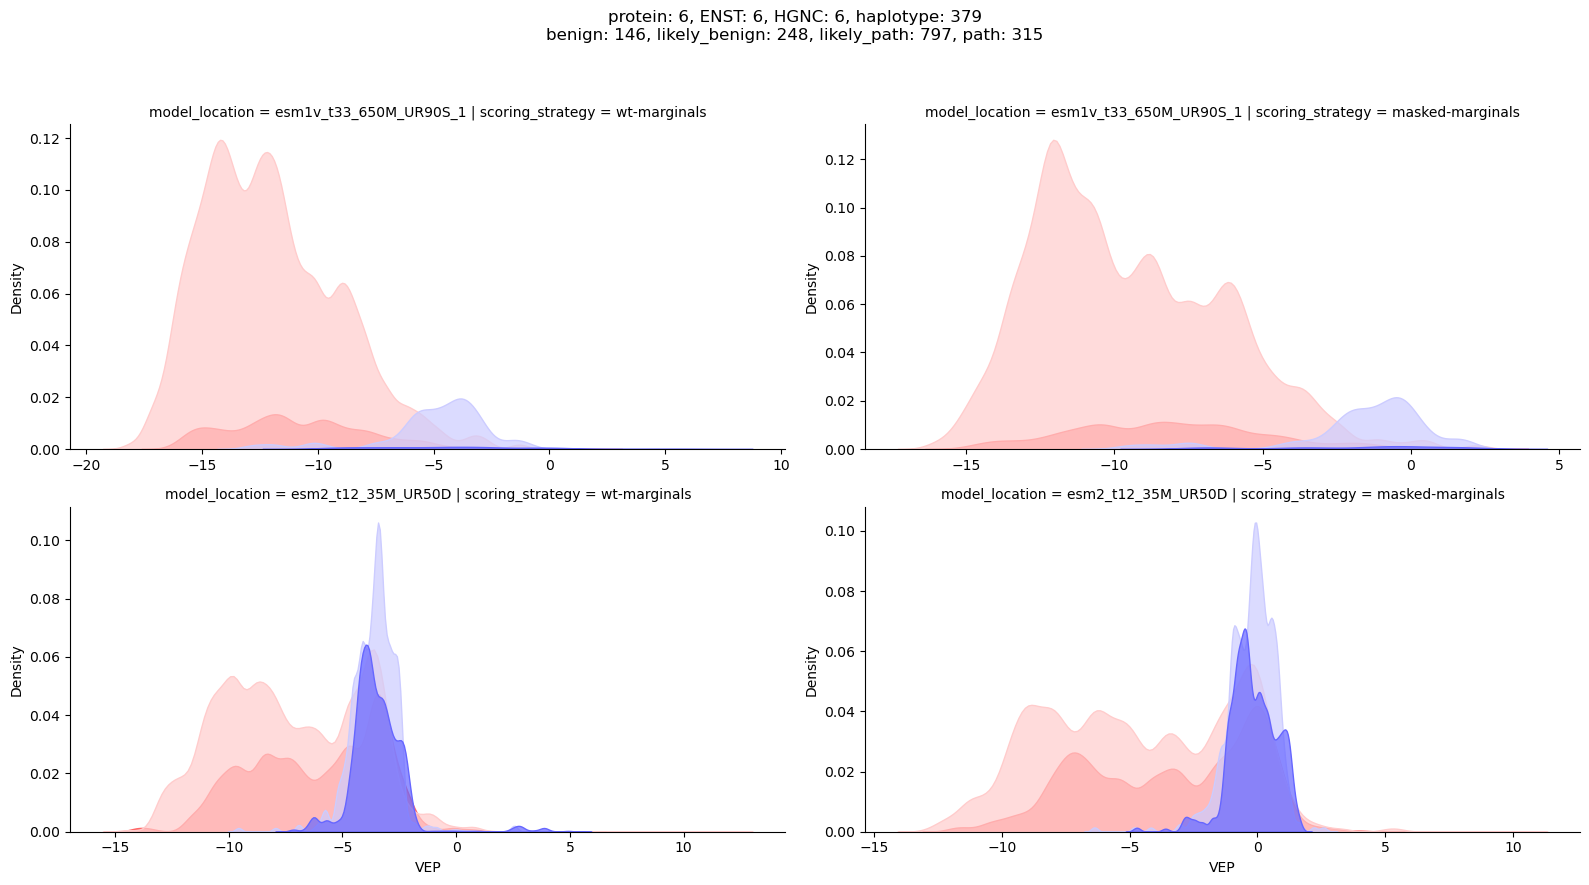

In [43]:
va.plot_vep_density(vep_df, 
                     multiple='layer')

Filtered 1.8% of rows with NAs in col 'VEP'


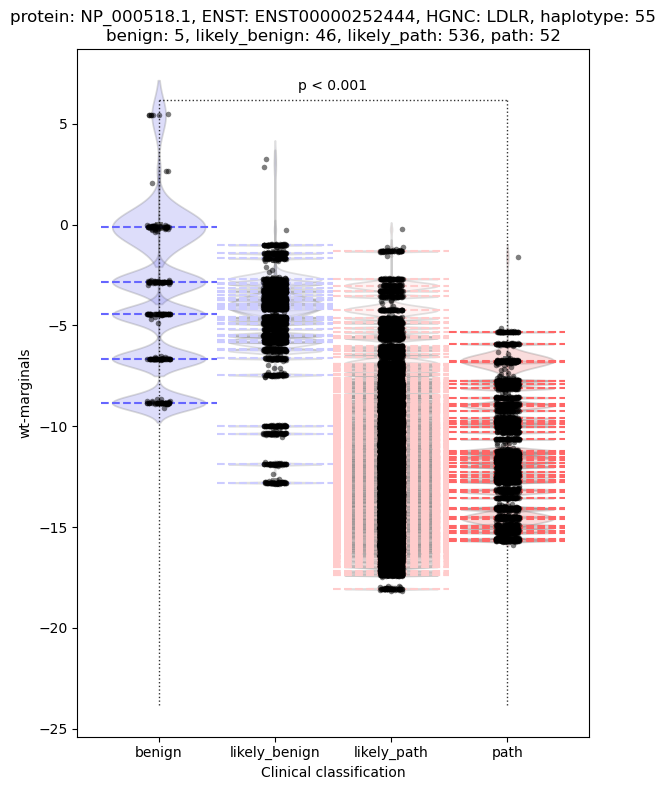

In [44]:
va.plot_vep_violin(vep_df, 
                    max_proteins=1,
                    max_models=1,
                    scoring_strategy="wt-marginals")

Filtered 1.8% of rows with NAs in col 'VEP'


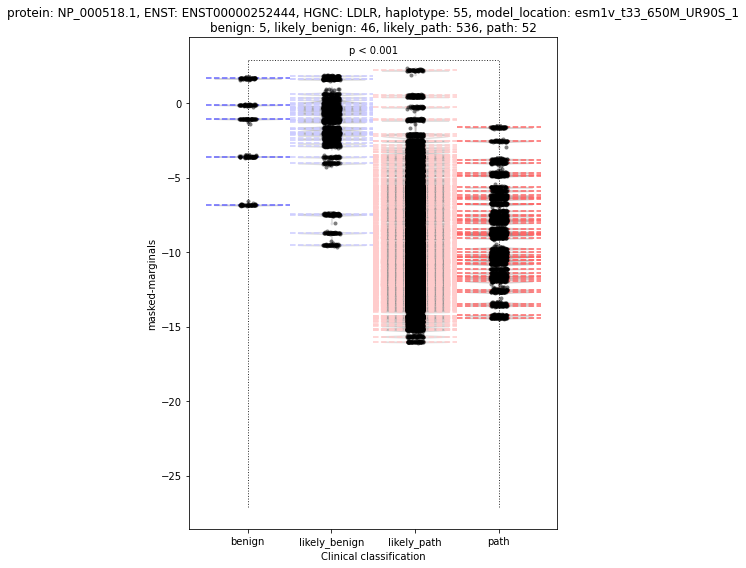

In [ ]:
va.plot_vep_violin(vep_df, 
                    max_proteins=1,
                    max_models=1,
                    scoring_strategy="masked-marginals")